We have to find the value for the employed state to perform the backwards induction. 

It is basically a cake eating problem where the remaining cake grows with a given rate and an absolute factor too. 
$A' = (1+R)(A+w-c)$

And the the bellman equation is: 
$V(A) = max_{c \in A+w} ln (c) + \beta   V [(1+R)(A+w-c)]  $ \\

Where we can substitute $c = w + A + A' / (1+R) $ to get: \\

$V(A) = max_{0 \le A' \le A+w} ln (w + A + A' / (1+R)) + \beta   V ( A' )  $

Which is a problem solely with A, that is given and A´ which is the optimizing factor. 

In [107]:
import numpy as np
from time import process_time
import matplotlib.pyplot as plt

Første problem er: Hvordan laver vi gridet, så det passer til at A' kan være større end A? 
Bertel har svaret. Det skal vi faktisk slet ikke tænke på, vi skal bare kunne ekstrapolere fra hver initial asset værdi. 
Husk: Vi forholder os altid kun til nuværende periode + næste fremtidige periode. Vi skal ikke forholde os til det scenarie, at opsparing vokser uendeligt
fordi vi kun løser nu og i morgen. 

In [101]:
from scipy import interpolate  # Interpolation routines
class ss_value:
    """Class to implement the stochastic cake eating model with discretized choice"""

    def __init__(self, beta=0.9, abar=[0, 20], n_a=50, n_c=100, w=15, R = 0.05 ):
        """Initializer"""
        self.beta = beta    # Discount factor
        self.abar = abar    # min and max savings
        self.n_a = n_a      # grid size for state variable
        self.n_c = n_c      # grid size for choice grid
        self.w = w          # wage
        self.R = R          # interest rate

        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
        # truncate lower bound at smallest positive float number
        # parameter dependent varibles
        self.a = np.linspace(self.abar[0], self.abar[1], n_a).reshape((n_a, 1))  # vi laver en vektor med state space fra 0 til abar og med det antal grid punkter vi vil have, n_a.  
        self.c = np.empty((n_a, n_c))  # starter consumption matrix med rækker for alle states og så et finere grid i kolonnerne for mulige consumption valg. 
        
        for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            self.c[i, :] = np.linspace(self.abar[0], self.a[i], n_c).reshape((1, n_c))  # vi laver hver række så den går fra '0' til den værdi i state grid, som vi kigger på. Altså, det vil svare til at vi kigger på alle mulige værdier for V(A=10)
                                                                                        # consumption choice bliver så lidt finere (det er kolonnerne her) og tager n_c grid points. 
                                                                                        # så hver række repræsenterer alle consumption choices givet en state value. 

        """Bellman operator, V0 is one-dim vector of values on state grid"""
    def bellman(self, V0, R):
        interp = interpolate.interp1d(self.a[:, 0], V0, bounds_error=False, fill_value="extrapolate")
        V = 0
        a1 = (self.a - self.c + self.w)*(1+R)       # vi laver a1 som funktion af hvad du forbruger
        V = interp(a1)
        
        matV1 = np.log(self.c) + self.beta * V  
        i_max = np.argmax(matV1, axis=1)
        # (column) index of optimal choices
        V1 = matV1[np.arange(self.n_a), i_max]          # her laver jeg en ny vektor, som indeholder nytten for alle de optimale værdier givet asset values. 
        c1 = self.c[np.arange(self.n_a), i_max]         # den her viser bare, hvor meget man har valgt at forbruge i perioden. 

        return V1, c1
    

Nu tilføjer vi value function solve mekanismen. 

In [102]:
def vfi(self, maxiter=1000, tol=1e-10, callback=None):
    """Solves the model using VFI (successive approximations)"""
    tic = process_time()  # Start the stopwatch / counter

    V0 = np.log(self.a[:, 0])  # on first iteration assume consuming everything
    for iter in range(maxiter):
        V1, c1 = self.bellman(V0, self.R)
        if callback:
            callback(iter, self.a, V1, c1)  # callback for making plots
        if np.all(abs(V1 - V0) < tol):
            toc = process_time()  # Stop the stopwatch / counter
            print("Optimal consumption of assets solved in", iter, "iterations, using", round(toc - tic, 5), "seconds")
            break
        V0 = V1
    else:  # when i went up to maxiter
        print("No convergence: maximum number of iterations achieved!")
    return V1, c1

# Add the vfi_solve method to the cake_stochastic class
ss_value.solve = vfi

Vi vil gerne have værdierne de endelige værdier ud for hver starting asset value. 

Vi kan lave den her for at man får et job og for hvis man aldrig nogensinde får et job. 
Den eneste ting som skal ændres der er så w. 

In [131]:
emp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=100, w=10, R=0.05)
V_emp, c_emp = emp.solve()

uemp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=100, w=5, R=0.05)
V_uemp, c_uemp = uemp.solve() 



Optimal consumption of assets solved in 465 iterations, using 0.069 seconds
Optimal consumption of assets solved in 458 iterations, using 0.04795 seconds


Optimal consumption of assets solved in 465 iterations, using 0.14217 seconds
Optimal consumption of assets solved in 458 iterations, using 0.12242 seconds


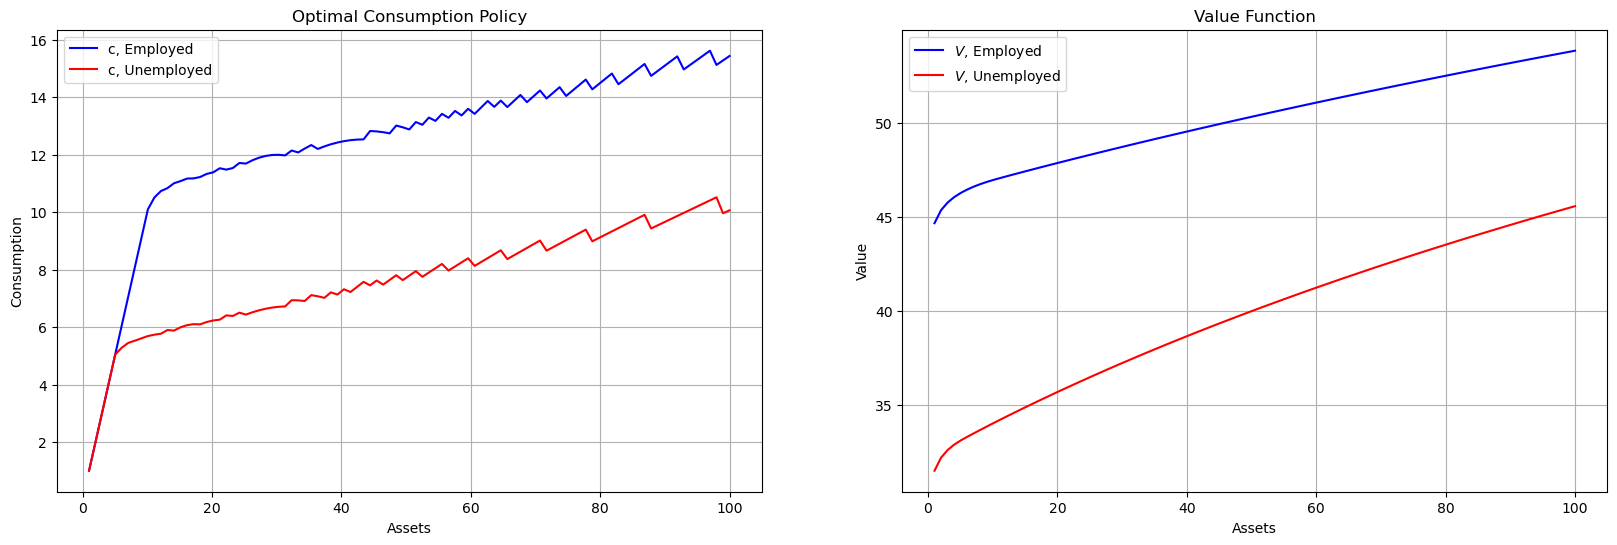

In [132]:
# vi laver plot for value og consumption rule for dem som ender i SS med arbejde og dem som ender i SS uden arbejde.

emp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=150, w=10, R=0.05)
V_emp, c_emp = emp.solve()

uemp = ss_value(beta=0.95, abar=[0, 100], n_a=50, n_c=150, w=5, R=0.05)
V_uemp, c_uemp = uemp.solve() 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
ax1.grid(True)
ax2.grid(True)
ax1.plot(emp.a[1:], c_emp[1:], color="b", label="c, Employed")
ax1.plot(emp.a[1:], c_uemp[1:], color="r", label="c, Unemployed")
ax1.set_xlabel("Assets")
ax1.set_ylabel("Consumption")
#max_c = c_emp.max()+5
#mask = emp.a[1:] <= max_c    # keeps the grid points until the max c value which is set dynamically for the consumption + something. 
#ax1.plot(emp.a[1:][mask], emp.a[1:][mask], color="k", label="45-degree line")  # We have to fix the scale of optimal consumption policy graph
#ax1.plot(emp.a[1:], emp.a[1:], color="k", label="45-degree line")      # We have to fix the scale of optimal consumption policy graph
ax1.legend()
ax1.set_title("Optimal Consumption Policy")
ax2.plot(emp.a[1:], V_emp[1:], color="b", label="$V$, Employed")
ax2.plot(emp.a[1:], V_uemp[1:], color="r", label="$V$, Unemployed")
ax2.legend()
ax2.set_title("Value Function")
ax2.set_xlabel("Assets")
ax2.set_ylabel("Value")
plt.show()

De burde jo ikke variere på den måde, men i stedet være roligt voksende funktioner. 

------------------------------------------------------------------------------------------------------------------------------------------------

Nu har vi steady state værdierne for nytte i evigheden givet asset values i sidste periode. 

Den præcist samme metode som ovenfor kan bruges til at finde nytten af unemployment. Vi skal blot indsætte en anden værdi af w.

Ud fra det kan vi vise i ovenstående plots, hvor meget nytten og forbruget ændrer sig ved at have et job og ikke have et job. 

Dem skal vi bruge til at løse det optimale forbrugsproblem via backwards induction.  

At løse det for arbejdet er det mindst komplicerede, fordi lønnen er konstant over hele perioden. 

Vi skal kun bruge 6 perioder. Én periode som er den sidste inden vi kigger efter steady state værdierne. 5 perioder, hvor agenten tilpasser sit referencepunkt til seneste periodes indkomst. 

Hvad skal vi bruge? 

1. Den nye nyttefunktion med et loss parameter. 
2. Referencepunktet for seneste periode.
    Det kan vi måske finde gennem income paths? 
3. Terminalværdien i sidste periode. Som er det vi har fået fra VFI. 
4. Derfra skal vi blot løse BI problemet. Det burde være helt okay. 

Nu ender vi et problem. vi skal bruge referencen fra seneste periode og nytteværdien for fremtidige periode... 

In [ ]:
def __init__(self, beta=0.9, abar=[0, 20], n_a=50, n_c=100, w=15, R = 0.05 ):
        """Initializer"""
        self.beta = beta    # Discount factor
        self.abar = abar    # min and max savings
        self.n_a = n_a      # grid size for state variable
        self.n_c = n_c      # grid size for choice grid
        self.w = w          # wage
        self.R = R          # interest rate

        self.abar[0] = np.maximum(np.finfo(float).eps, self.abar[0])       # vælger den højeste værdi af minimumsværdien for abar og 'numerisk 0'. Vi vil ikke under numerisk 0.  
        # truncate lower bound at smallest positive float number
        # parameter dependent varibles
        self.a = np.linspace(self.abar[0], self.abar[1], n_a).reshape((n_a, 1))  # vi laver en vektor med state space fra 0 til abar og med det antal grid punkter vi vil have, n_a.  
        self.c = np.empty((n_a, n_c))  # starter consumption matrix med rækker for alle states og så et finere grid i kolonnerne for mulige consumption valg. 
        
        for i in range(n_a):            # fordi rækkerne er state-grids, så derfor skal vi have en række for hver state vi vil kigge på
            self.c[i, :] = np.linspace(self.abar[0], self.a[i], n_c).reshape((1, n_c))  # vi laver hver række så den går fra '0' til den værdi i state grid, som vi kigger på. Altså, det vil svare til at vi kigger på alle mulige værdier for V(A=10)
                                           

In [91]:
class ref_inc_path():
    def __init__(self,w =15, b1=10, b2 = 8, b3 = 6, welfare = 4, T1 = 12, T2 = 36, T3 = 48, T = 54 ):
        self.w = w
        self.b1 = b1
        self.b2 = b2
        self.b3 = b3
        self.welfare = welfare
        self.T1 = T1
        self.T2 = T2
        self.T3 = T3
        self.T = T

    def benefit_path(self, b1,b2,b3,welfare,T1,T2,T3,T):                # vi laver income paths som en T, array med alle income levels for forskellige perioder
        '''
        Returns the benefit path given parameter values.
            Arguments:
                b1,b2,b3,welfare (all floats): values at distinct time windows during unemployment
                T1,T2,T3 (int): points in Unemp. spell when benefit levels change.
                T (int): Total number of periods
            Returns:
                benefits (array): Benefit path in unemployment
        '''
        benefits        = np.zeros(T)       # Laver en vektor med T, elementer. 
        benefits[0:self.T1]  = self.b1                # for de rigtige tidspunkter tilføjer den benefit levels. 
        benefits[self.T1:self.T2] = self.b2
        benefits[self.T2:self.T3] = self.b3
        benefits[self.T3:self.T]  = self.welfare

        return benefits
    

    def income_path(self):                          
        '''Laver alle de mulige income paths. 
            En for alle tidspunkter hvorpå man finder et job, inklusiv muligheden for aldrig at finde et job
        '''
        benefits = self.benefit_path()
        income_path = np.tile(benefits,(self.T+1,1))
        for j in np.arange(self.T): 
            income_path[j,j:] = self.w
        return income_path
    
    def ref_path(self):             # the reference point is given as the arithmetic average of the income in the 5 periods leading up to the current one. 
        


In [87]:
# UI benefit level b as function of time
def benefit_path(b1,b2,b3,welfare,T1,T2,T3,T):
    '''
    Returns the benefit path given parameter values.
        Arguments:
            b1,b2,b3,welfare (all floats): values at distinct time windows during unemployment
            T1,T2,T3 (int): points in Unemp. spell when benefit levels change.
            T (int): Total number of periods
        Returns:
            benefits (array): Benefit path in unemployment
    '''
    benefits        = np.zeros(T)       # Laver en vektor med T, elementer. 
    benefits[0:T1]  = b1                # for de rigtige tidspunkter tilføjer den benefit levels. 
    benefits[T1:T2] = b2
    benefits[T2:T3] = b3
    benefits[T3:T]  = welfare

    return benefits

In [88]:
# vi starter med at lave income path. Vi kan gøre det inde i en class måske?

income_path = np.tile(benefits,(T+1,1))
for j in np.arange(T): 
    income_path[j,j:] = w


NameError: name 'benefits' is not defined

In [ ]:
def vfi(self, maxiter=1000, tol=1e-10, callback=None):
    """Solves the model using VFI (successive approximations)"""
    tic = process_time()  # Start the stopwatch / counter

    V0 = np.log(self.a[:, 0])  # on first iteration assume consuming everything
    for iter in range(maxiter):
        V1, c1 = self.bellman(V0, self.R)
        if callback:
            callback(iter, self.a, V1, c1)  # callback for making plots
        if np.all(abs(V1 - V0) < tol):
            toc = process_time()  # Stop the stopwatch / counter
            print("Optimal consumption of assets solved in", iter, "iterations, using", round(toc - tic, 5), "seconds")
            break
        V0 = V1
    else:  # when i went up to maxiter
        print("No convergence: maximum number of iterations achieved!")
    return V1, c1